<a href="https://colab.research.google.com/github/diabetico2/trabalho-final-IA/blob/main/Trabalho%20IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive

# 1. Conecta o seu Google Drive ao Colab
drive.mount('/content/drive')

# 2. Extrai o ZIP do seu Drive direto para a memória rápida do Colab
!unzip -q /content/drive/MyDrive/colabIA/archive.zip -d dataset/

print("\nImagens extraídas com sucesso para a memória rápida!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Imagens extraídas com sucesso para a memória rápida!


Resumo da quantidade de imagens:


Quantidade
Conjunto Classe                         
test     Covid-19                    300
         Emphysema                   250
         Normal                      300
         Pneumonia-Bacterial         300
         Pneumonia-Viral             300
         Tuberculosis                287
train    Covid-19                   2417
         Emphysema                  2050
         Normal                     2671
         Pneumonia-Bacterial        2400
         Pneumonia-Viral            2413
         Tuberculosis               2600
val      Covid-19                    300
         Emphysema                   250
         Normal                      300
         Pneumonia-Bacterial         300
         Pneumonia-Viral             300
         Tuberculosis                298

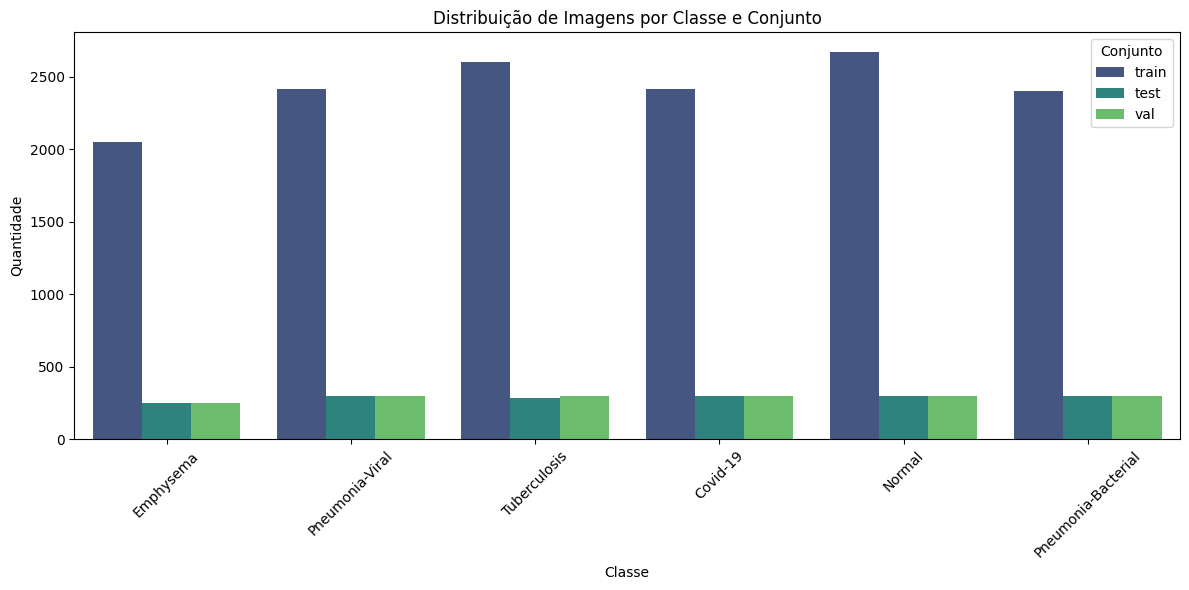

In [8]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

caminho_base = 'dataset'
dataset_path = None

for root, dirs, files in os.walk(caminho_base):
    if 'train' in dirs and 'test' in dirs:
        dataset_path = root
        break

if dataset_path is not None:
    pastas = ['train', 'test', 'val']
    dados = []

    for pasta in pastas:
        caminho_pasta = os.path.join(dataset_path, pasta)
        if os.path.exists(caminho_pasta):
            classes = os.listdir(caminho_pasta)
            for nome_classe in classes:
                caminho_classe = os.path.join(caminho_pasta, nome_classe)
                if os.path.isdir(caminho_classe):
                    dados.append({'Conjunto': pasta, 'Classe': nome_classe, 'Quantidade': len(os.listdir(caminho_classe))})

    df = pd.DataFrame(dados)
    print("Resumo da quantidade de imagens:")
    display(df.groupby(['Conjunto', 'Classe']).sum())

    plt.figure(figsize=(12, 6))
    sns.barplot(data=df, x='Classe', y='Quantidade', hue='Conjunto', palette='viridis')
    plt.title('Distribuição de Imagens por Classe e Conjunto')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [9]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

caminho_base = 'dataset'
dataset_path = None
for root, dirs, files in os.walk(caminho_base):
    if 'train' in dirs and 'val' in dirs:
        dataset_path = root
        break

train_dir = os.path.join(dataset_path, 'train')
val_dir = os.path.join(dataset_path, 'val')

IMG_HEIGHT, IMG_WIDTH, BATCH_SIZE = 224, 224, 32

train_datagen = ImageDataGenerator(
    rescale=1./255, rotation_range=20, zoom_range=0.15,
    width_shift_range=0.1, height_shift_range=0.1, horizontal_flip=True
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

print("--- Carregando Imagens ---")
train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=(IMG_HEIGHT, IMG_WIDTH), batch_size=BATCH_SIZE, class_mode='categorical'
)
val_generator = val_test_datagen.flow_from_directory(
    val_dir, target_size=(IMG_HEIGHT, IMG_WIDTH), batch_size=BATCH_SIZE, class_mode='categorical'
)

num_classes = len(train_generator.class_indices)

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    BatchNormalization(), MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(), MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(), MaxPooling2D((2, 2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

--- Carregando Imagens ---
Found 14551 images belonging to 6 classes.
Found 1748 images belonging to 6 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,247,110 (84.87 MB)

 Trainable params: 22,246,662 (84.86 MB)

 Non-trainable params: 448 (1.75 KB)

In [10]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Caminho para salvar o modelo DIRETO no seu Google Drive (na pasta colabIA)
caminho_salvar_modelo = '/content/drive/MyDrive/colabIA/melhor_modelo_raiox.keras'

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint(caminho_salvar_modelo, monitor='val_accuracy', save_best_only=True)

EPOCHS = 20

print("--- Iniciando o Treinamento da IA ---")
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[early_stop, checkpoint]
)
print(f"\n--- Treinamento Concluído! O modelo foi salvo em segurança no seu Drive: {caminho_salvar_modelo} ---")

--- Iniciando o Treinamento da IA ---
Epoch 1/20
455/455 ━━━━━━━━━━━━━━━━━━━━ 212s 445ms/step - accuracy: 0.4027 - loss: 3.8053 - val_accuracy: 0.2872 - val_loss: 3.3642
Epoch 2/20
455/455 ━━━━━━━━━━━━━━━━━━━━ 189s 416ms/step - accuracy: 0.4511 - loss: 1.3245 - val_accuracy: 0.2866 - val_loss: 62.9178
Epoch 3/20
455/455 ━━━━━━━━━━━━━━━━━━━━ 194s 426ms/step - accuracy: 0.5094 - loss: 1.1405 - val_accuracy: 0.3398 - val_loss: 5.8794
Epoch 4/20
455/455 ━━━━━━━━━━━━━━━━━━━━ 201s 441ms/step - accuracy: 0.5304 - loss: 1.0559 - val_accuracy: 0.5423 - val_loss: 1.2791
Epoch 5/20
455/455 ━━━━━━━━━━━━━━━━━━━━ 193s 423ms/step - accuracy: 0.5499 - loss: 0.9963 - val_accuracy: 0.4022 - val_loss: 2.5608
Epoch 6/20
455/455 ━━━━━━━━━━━━━━━━━━━━ 187s 410ms/step - accuracy: 0.5400 - loss: 1.0331 - val_accuracy: 0.4428 - val_loss: 2.1523
Epoch 7/20
455/455 ━━━━━━━━━━━━━━━━━━━━ 189s 416ms/step - accuracy: 0.5590 - loss: 0.9565 - val_accuracy: 0.4600 - val_loss: 2.2655
Epoch 8/20
455/455 ━━━━━━━━━━━━━━━━━━

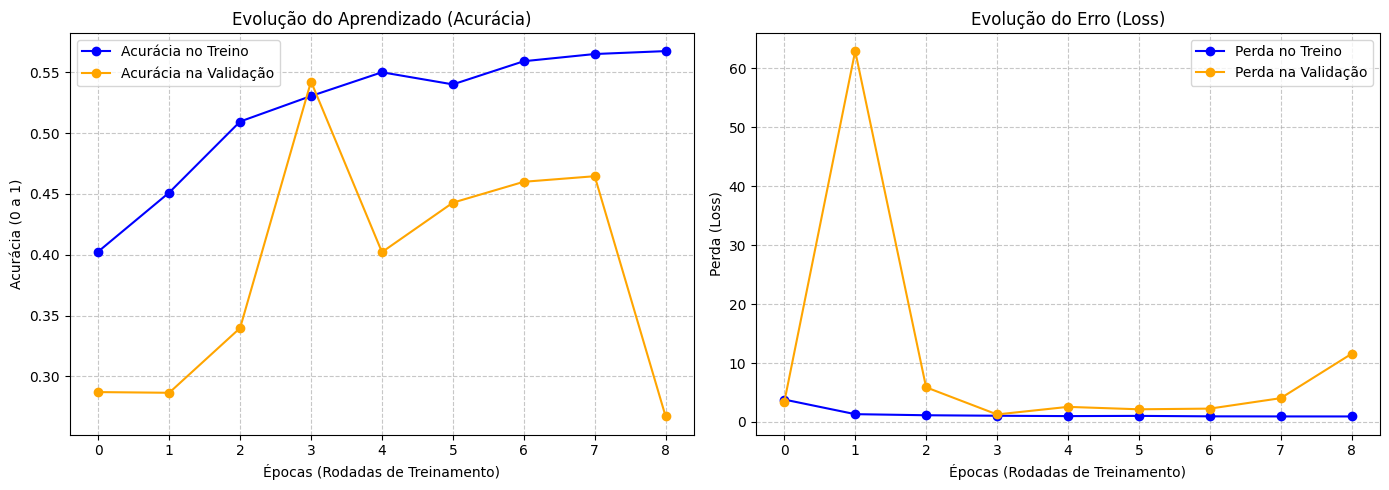

In [11]:
import matplotlib.pyplot as plt

# Configuração do tamanho da imagem
plt.figure(figsize=(14, 5))

# 1. Gráfico de Acurácia (Taxa de Acertos)
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Acurácia no Treino', color='blue', marker='o')
plt.plot(history.history['val_accuracy'], label='Acurácia na Validação', color='orange', marker='o')
plt.title('Evolução do Aprendizado (Acurácia)')
plt.xlabel('Épocas (Rodadas de Treinamento)')
plt.ylabel('Acurácia (0 a 1)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# 2. Gráfico de Perda (Taxa de Erros)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Perda no Treino', color='blue', marker='o')
plt.plot(history.history['val_loss'], label='Perda na Validação', color='orange', marker='o')
plt.title('Evolução do Erro (Loss)')
plt.xlabel('Épocas (Rodadas de Treinamento)')
plt.ylabel('Perda (Loss)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Mostrar os gráficos
plt.tight_layout()
plt.show()

--- Carregando o cérebro da IA do Drive ---
Found 1737 images belonging to 6 classes.

--- Aplicando a 'Prova Final' nas Imagens de Teste ---
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 121ms/step


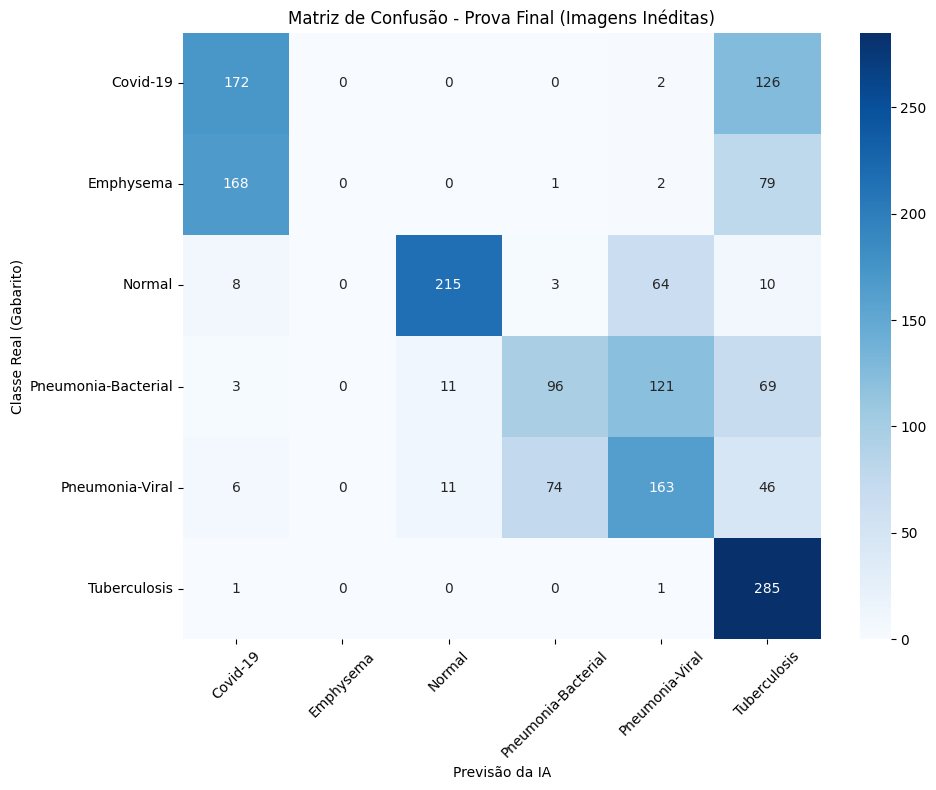


--- Relatório Final de Desempenho ---
                     precision    recall  f1-score   support

           Covid-19       0.48      0.57      0.52       300
          Emphysema       0.00      0.00      0.00       250
             Normal       0.91      0.72      0.80       300
Pneumonia-Bacterial       0.55      0.32      0.41       300
    Pneumonia-Viral       0.46      0.54      0.50       300
       Tuberculosis       0.46      0.99      0.63       287

           accuracy                           0.54      1737
          macro avg       0.48      0.52      0.48      1737
       weighted avg       0.49      0.54      0.49      1737



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [12]:
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Carregar o melhor modelo salvo no seu Drive
caminho_modelo = '/content/drive/MyDrive/colabIA/melhor_modelo_raiox.keras'
print("--- Carregando o cérebro da IA do Drive ---")
modelo_salvo = load_model(caminho_modelo)

# Encontrar a pasta de teste
caminho_base = 'dataset'
dataset_path = None
for root, dirs, files in os.walk(caminho_base):
    if 'test' in dirs:
        dataset_path = root
        break

test_dir = os.path.join(dataset_path, 'test')

# 2. Preparar as imagens de Teste
# MUITO IMPORTANTE: shuffle=False para que a IA não embaralhe a ordem e a gente possa corrigir a prova direito
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

print("\n--- Aplicando a 'Prova Final' nas Imagens de Teste ---")
# 3. Fazer as previsões
previsoes = modelo_salvo.predict(test_generator)
previsoes_classes = np.argmax(previsoes, axis=1) # Pega a doença com maior probabilidade
classes_reais = test_generator.classes           # O gabarito correto
nomes_classes = list(test_generator.class_indices.keys())

# 4. Gerar e plotar a Matriz de Confusão
cm = confusion_matrix(classes_reais, previsoes_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=nomes_classes, yticklabels=nomes_classes)
plt.title('Matriz de Confusão - Prova Final (Imagens Inéditas)')
plt.ylabel('Classe Real (Gabarito)')
plt.xlabel('Previsão da IA')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 5. Relatório de Classificação
print("\n--- Relatório Final de Desempenho ---")
print(classification_report(classes_reais, previsoes_classes, target_names=nomes_classes))